# Object + Classification

### Data Engineering

##### Data Preview

In [1]:
import os
data_root_path = "../../dataset_resplit_aug_1"
dir = os.listdir(data_root_path)
print(dir)

['data.yaml', 'test', 'train', 'valid']


In [2]:
import os
import glob
from collections import Counter
import pandas as pd

data_root_path = "../../dataset_resplit_aug_1"
splits = ["train", "test", "valid"]

summary = {}

for split in splits:
    split_path = os.path.join(data_root_path, split)
    labels_path = os.path.join(split_path, "labels")

    if not os.path.isdir(labels_path):
        print(f"❌ {split}/labels folder not found")
        continue

    label_files = glob.glob(os.path.join(labels_path, "*.txt"))
    
    class_counter = Counter()

    for file in label_files:
        with open(file, "r") as f:
            lines = f.readlines()
            for line in lines:
                class_id = float(line.strip().split()[0])
                class_counter[class_id] += 1

    summary[split] = class_counter

    print(f"\n{split}:")
    for cls, count in sorted(class_counter.items()):
        print(f"Class {cls}: {count}")

# Optional: convert to DataFrame
df_summary = pd.DataFrame(summary).fillna(0).astype(int)
print("\nCombined Summary:")
print(df_summary)



train:
Class 0.0: 212
Class 1.0: 584
Class 2.0: 448
Class 3.0: 488
Class 4.0: 508
Class 5.0: 516

test:
Class 0.0: 11
Class 1.0: 20
Class 2.0: 14
Class 3.0: 20
Class 4.0: 19
Class 5.0: 15

valid:
Class 0.0: 28
Class 1.0: 64
Class 2.0: 86
Class 3.0: 76
Class 4.0: 68
Class 5.0: 72

Combined Summary:
     train  test  valid
0.0    212    11     28
1.0    584    20     64
2.0    448    14     86
3.0    488    20     76
4.0    508    19     68
5.0    516    15     72


##### New 2 States Model (DATASET)

In [3]:
import os
import glob
import torch
from torch.utils.data import Dataset
from PIL import Image

class YOLODetectionDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        self.images_dir = os.path.join(root_dir, split, "images")
        self.labels_dir = os.path.join(root_dir, split, "labels")

        self.image_paths = sorted(
            glob.glob(os.path.join(self.images_dir, "*.jpg"))
        )

        print(f"📂 Loaded {split} set")
        print(f"🖼️ Images: {len(self.image_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_path = os.path.join(
            self.labels_dir,
            os.path.basename(img_path).replace(".jpg", ".txt")
        )

        image = Image.open(img_path).convert("RGB")
        w, h = image.size

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, x_center, y_center, bw, bh = map(float, line.strip().split())

                    # Convert YOLO → Pascal VOC
                    x1 = (x_center - bw / 2) * w
                    y1 = (y_center - bh / 2) * h
                    x2 = (x_center + bw / 2) * w
                    y2 = (y_center + bh / 2) * h

                    boxes.append([float(x1), float(y1), float(x2), float(y2)])
                    labels.append(float(cls))

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        target = {
            "boxes": boxes,
            "labels": labels
        }

        if self.transform:
            image = self.transform(image)
        else:
            image = torch.tensor(
                torch.ByteTensor(torch.ByteStorage.from_buffer(image.tobytes()))
            )

        return image, labels, boxes


In [4]:
class YOLODetectionDataset(Dataset):
    def __init__(self, root_dir, split="train", transform=None):
        self.root_dir = root_dir
        self.split = split
        self.transform = transform

        self.images_dir = os.path.join(root_dir, split, "images")
        self.labels_dir = os.path.join(root_dir, split, "labels")

        self.image_paths = sorted(
            glob.glob(os.path.join(self.images_dir, "*.jpg"))
        )

        print(f"📂 Loaded {split} set")
        print(f"🖼️ Images: {len(self.image_paths)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label_path = os.path.join(
            self.labels_dir,
            os.path.basename(img_path).replace(".jpg", ".txt")
        )

        image = Image.open(img_path).convert("RGB")

        boxes = []
        labels = []

        if os.path.exists(label_path):
            with open(label_path, "r") as f:
                for line in f.readlines():
                    cls, x_center, y_center, bw, bh = map(float, line.strip().split())

                    # ✅ เก็บแบบ YOLO normalized เลย
                    boxes.append([x_center, y_center, bw, bh])
                    labels.append(int(cls))

        boxes = torch.tensor(boxes, dtype=torch.float32)
        labels = torch.tensor(labels, dtype=torch.int64)

        if self.transform:
            image = self.transform(image)

        return image, labels, boxes

In [5]:
from torchvision import transforms

mean_ds, std_ds = torch.tensor([0.5775, 0.5520, 0.5217]), torch.tensor([0.2166, 0.2153, 0.2235])
valid_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ds, std=std_ds)
])

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_ds, std=std_ds)
])
root = "../../dataset_resplit_aug_1"
train_dataset = YOLODetectionDataset(root, split="train", transform=train_transform)
valid_dataset = YOLODetectionDataset(root, split="valid", transform=valid_transform)
test_dataset = YOLODetectionDataset(root, split="test", transform=valid_transform)

print(f"✅ Train samples: {len(train_dataset)}")
print(f"✅ Valid samples: {len(valid_dataset)}")
print(f"✅ Test samples: {len(test_dataset)}")

📂 Loaded train set
🖼️ Images: 2756
📂 Loaded valid set
🖼️ Images: 394
📂 Loaded test set
🖼️ Images: 99
✅ Train samples: 2756
✅ Valid samples: 394
✅ Test samples: 99


In [6]:
import torch
from torchvision import transforms
from torch.utils.data import DataLoader
import numpy as np
from tqdm import tqdm
from tqdm import tqdm
import torch
from torch.utils.data import DataLoader

In [7]:
train_loader = DataLoader( train_dataset, batch_size=16, shuffle=True)
valid_loader = DataLoader( valid_dataset, batch_size=16, shuffle=False)
test_loader = DataLoader( test_dataset, batch_size=16, shuffle=False)

### Model selection

[เลือกโมเดลที่นี่](https://docs.pytorch.org/vision/main/models.html) แล้วเอาไปแก้ที่ Import

from torchvision.models แล้วไปแก้ที่บรรทัด 14-15



#### Model training

In [8]:
def calculate_iou(box1, box2):
    x_left = max(box1[0], box2[0])
    y_top = max(box1[1], box2[1])
    x_right = min(box1[2], box2[2])
    y_bottom = min(box1[3], box2[3])

    if x_right < x_left or y_bottom < y_top:
        return 0.0 # ไม่ทับกันเลย
    intersection_area = (x_right - x_left) * (y_bottom - y_top)
    box1_area = (box1[2] - box1[0]) * (box1[3] - box1[1])
    box2_area = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union_area = box1_area + box2_area - intersection_area
    return intersection_area / union_area

In [9]:
def manual_nms(boxes, scores, iou_threshold=0.1):
    idxs = scores.argsort(descending=True)
    keep = []

    while len(idxs) > 0:
        current = idxs[0]
        keep.append(current.item()) # เก็บกล่องที่มั่นใจที่สุดไว้

        if len(idxs) == 1: break
        remaining_idxs = idxs[1:]
        filtered_idxs = []
        for i in remaining_idxs:
            iou = calculate_iou(boxes[current], boxes[i])
            if iou < iou_threshold:
                filtered_idxs.append(i)
        idxs = torch.tensor(filtered_idxs)
    return torch.tensor(keep)

In [10]:
import torch
import torch.nn as nn

class MultiBoxLoss(nn.Module):
    def __init__(self, num_classes, grid_size=7):
        super(MultiBoxLoss, self).__init__()
        self.num_classes = num_classes
        self.grid_size = grid_size
        self.mse_loss = nn.MSELoss(reduction='sum')
        self.ce_loss = nn.CrossEntropyLoss()
        self.bce_loss = nn.BCEWithLogitsLoss(reduction='sum')

    def forward(self, predictions, target_boxes, target_labels):
        batch_size = predictions.size(0)
        device = predictions.device
        loc_l, obj_l, cls_l = torch.tensor(0.0, device=device), torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)

        # วนลูปราย Batch
        for i in range(batch_size):
            pred = predictions[i] # [Anchors, Hg, Wg, 5 + C]
            gt_boxes = target_boxes[i]
            gt_labels = target_labels[i]

            # 1. Background (No Object) Loss
            # สร้าง target เป็น 0 ทั้งหมดสำหรับทุก Grid cells
            obj_target = torch.zeros(pred.shape[0], pred.shape[1], device=device)

            # 2. Positive Case (Match Ground Truth)
            for j, box in enumerate(gt_boxes):
                # คำนวณหาตำแหน่ง Grid (0.0 - 1.0 -> 0 - 6)
                gx, gy = box[0] * self.grid_size, box[1] * self.grid_size
                grid_i, grid_j = int(gx.clamp(0, self.grid_size-1)), int(gy.clamp(0, self.grid_size-1))

                # มาร์คตำแหน่งนี้ว่ามีวัตถุ (Target = 1)
                obj_target[grid_j, grid_i] = 1.0

                # ดึง Prediction เฉพาะจุดนั้นมาคำนวณ Loc และ Class
                target_pred = pred[grid_j, grid_i]
                loc_l += self.mse_loss(target_pred[:4], box)
                cls_l += self.ce_loss(target_pred[5:].unsqueeze(0), gt_labels[j].unsqueeze(0))

            # 3. Objectness Loss (คำนวณทีเดียวทั้ง Grid เพื่อความเร็ว)
            obj_l += self.bce_loss(pred[:, :, 4], obj_target)

        total_l = (loc_l + obj_l + cls_l) / batch_size
        return total_l, loc_l/batch_size, obj_l/batch_size, cls_l/batch_size

In [11]:
def get_iou(box1, box2):
    """
    คำนวณ IoU ระหว่างกล่องสองใบ (Center Format: [cx, cy, w, h])
    """
    # แปลง Center [cx, cy, w, h] -> Corners [x1, y1, x2, y2]
    b1_x1, b1_y1 = box1[0] - box1[2]/2, box1[1] - box1[3]/2
    b1_x2, b1_y2 = box1[0] + box1[2]/2, box1[1] + box1[3]/2
    b2_x1, b2_y1 = box2[0] - box2[2]/2, box2[1] - box2[3]/2
    b2_x2, b2_y2 = box2[0] + box2[2]/2, box2[1] + box2[3]/2

    # หาพื้นที่ทับกัน (Intersection)
    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)

    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter_area = inter_w * inter_h

    # คำนวณพื้นที่รวม (Union)
    b1_area = box1[2] * box1[3]
    b2_area = box2[2] * box2[3]
    union_area = b1_area + b2_area - inter_area

    return inter_area / (union_area + 1e-6)

def run_epoch(model, loader, optimizer, criterion, device, is_train=True):
    if is_train:
        model.train()
    else:
        model.eval()

    metrics = {
        'all': 0,
        'bboxes': 0,
        'classes': 0,
        'obj': 0,
        'cls_acc': 0,  # ความแม่นยำในการทายพันธุ์แมว
        'avg_iou': 0   # ความแม่นยำในการวาดกล่อง (0.0 - 1.0)
    }

    total_samples = 0
    grid_size = 7 # ปรับให้ตรงกับโมเดล (DenseNet/ResNet มักเป็น 7x7 สำหรับภาพ 224)

    with torch.set_grad_enabled(is_train):
        for images, labels, boxes in loader:
            images = images.to(device)
            # labels และ boxes เป็น List ของ Tensor เนื่องจากแต่ละภาพมีจำนวนวัตถุไม่เท่ากัน
            labels = [l.to(device) for l in labels]
            boxes = [b.to(device) for b in boxes]

            if is_train:
                optimizer.zero_grad()

            # Forward Pass
            det_out = model(images)

            # Loss Calculation
            loss_all, loss_loc, loss_obj, loss_cls = criterion(det_out, boxes, labels)

            if is_train:
                loss_all.backward()
                optimizer.step()

            # --- Metrics Calculation ---
            with torch.no_grad():
                batch_cls_corr = 0
                batch_iou_sum = 0
                total_objects_in_batch = 0

                for i in range(len(labels)):
                    gt_labels = labels[i]
                    gt_boxes = boxes[i]

                    for j in range(len(gt_labels)):
                        # หาตำแหน่ง Grid ที่วัตถุนั้นอยู่
                        gx = int(gt_boxes[j][0] * grid_size)
                        gy = int(gt_boxes[j][1] * grid_size)
                        gx, gy = max(0, min(gx, grid_size-1)), max(0, min(gy, grid_size-1))

                        # 1. วัดค่า IoU (ความแม่นยำของตำแหน่งกล่อง)
                        pred_box = det_out[i, gy, gx, :4]
                        
                        current_iou = get_iou(pred_box, gt_boxes[j])
                        batch_iou_sum += current_iou.item()

                        # 2. วัดค่า Class Accuracy (ทายพันธุ์ถูกไหม)
                        pred_class_logits = det_out[i, gy, gx, 5:]
                        if torch.argmax(pred_class_logits) == gt_labels[j]:
                            batch_cls_corr += 1

                        total_objects_in_batch += 1

                # เก็บค่าเฉลี่ยราย Batch
                if total_objects_in_batch > 0:
                    metrics['cls_acc'] += (batch_cls_corr / total_objects_in_batch)
                    metrics['avg_iou'] += (batch_iou_sum / total_objects_in_batch)

                metrics['all'] += loss_all.item()
                metrics['bboxes'] += loss_loc.item()
                metrics['obj'] += loss_obj.item()
                metrics['classes'] += loss_cls.item()
                total_samples += 1

    # หารด้วยจำนวน batch เพื่อหาค่าเฉลี่ยต่อ Epoch
    for key in metrics:
        metrics[key] /= len(loader)

    return metrics

In [ ]:
def calculate_iou(box1, box2):
    """
    box format: [x1, y1, x2, y2]
    รองรับ torch tensor
    """
    x_left = torch.max(box1[0], box2[0])
    y_top = torch.max(box1[1], box2[1])
    x_right = torch.min(box1[2], box2[2])
    y_bottom = torch.min(box1[3], box2[3])

    inter_w = torch.clamp(x_right - x_left, min=0)
    inter_h = torch.clamp(y_bottom - y_top, min=0)
    intersection_area = inter_w * inter_h

    box1_area = torch.clamp(box1[2] - box1[0], min=0) * torch.clamp(box1[3] - box1[1], min=0)
    box2_area = torch.clamp(box2[2] - box2[0], min=0) * torch.clamp(box2[3] - box2[1], min=0)

    union_area = box1_area + box2_area - intersection_area + 1e-6

    return intersection_area / union_area

def manual_nms(boxes, scores, iou_threshold=0.5):
    """
    boxes: Tensor [N, 4]
    scores: Tensor [N]
    """
    idxs = scores.argsort(descending=True)
    keep = []

    while idxs.numel() > 0:
        current = idxs[0]
        keep.append(current)

        if idxs.numel() == 1:
            break

        remaining = idxs[1:]
        ious = torch.stack([
            calculate_iou(boxes[current], boxes[i])
            for i in remaining
        ])

        idxs = remaining[ious < iou_threshold]

    return torch.stack(keep)

def get_iou(box1, box2):
    """
    box format: [cx, cy, w, h]
    """

    # convert to corners
    b1_x1 = box1[0] - box1[2] / 2
    b1_y1 = box1[1] - box1[3] / 2
    b1_x2 = box1[0] + box1[2] / 2
    b1_y2 = box1[1] + box1[3] / 2

    b2_x1 = box2[0] - box2[2] / 2
    b2_y1 = box2[1] - box2[3] / 2
    b2_x2 = box2[0] + box2[2] / 2
    b2_y2 = box2[1] + box2[3] / 2

    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)

    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter_area = inter_w * inter_h

    b1_area = box1[2] * box1[3]
    b2_area = box2[2] * box2[3]

    union = b1_area + b2_area - inter_area + 1e-6

    return inter_area / union

def compute_ap(pred_boxes, pred_scores,
               gt_boxes,
               iou_threshold=0.5):

    if len(pred_boxes) == 0:
        return 0.0

    # เรียงตาม confidence
    sorted_idx = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[sorted_idx]

    tp = torch.zeros(len(pred_boxes))
    fp = torch.zeros(len(pred_boxes))

    matched_gt = []

    for i in range(len(pred_boxes)):

        best_iou = 0
        best_gt_idx = -1

        for j in range(len(gt_boxes)):
            iou = calculate_iou(pred_boxes[i], gt_boxes[j])

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
            tp[i] = 1
            matched_gt.append(best_gt_idx)
        else:
            fp[i] = 1

    tp_cum = torch.cumsum(tp, dim=0)
    fp_cum = torch.cumsum(fp, dim=0)

    recalls = tp_cum / (len(gt_boxes) + 1e-6)
    precisions = tp_cum / (tp_cum + fp_cum + 1e-6)

    ap = torch.trapz(precisions, recalls)

    return ap.item()

def compute_map50(all_preds, all_targets, num_classes):
    aps = []

    for cls in range(num_classes):

        cls_pred_boxes = []
        cls_pred_scores = []
        cls_gt_boxes = []

        for preds, targets in zip(all_preds, all_targets):

            mask_pred = preds["labels"] == cls
            mask_gt = targets["labels"] == cls

            cls_pred_boxes.append(preds["boxes"][mask_pred])
            cls_pred_scores.append(preds["scores"][mask_pred])
            cls_gt_boxes.append(targets["boxes"][mask_gt])

        if len(cls_gt_boxes) == 0:
            continue

        pred_boxes = torch.cat(cls_pred_boxes) if len(cls_pred_boxes) > 0 else torch.empty((0,4))
        pred_scores = torch.cat(cls_pred_scores) if len(cls_pred_scores) > 0 else torch.empty((0,))
        gt_boxes = torch.cat(cls_gt_boxes)

        ap = compute_ap(pred_boxes,
                pred_scores,
                gt_boxes,
                iou_threshold=0.05)

        aps.append(ap)

    if len(aps) == 0:
        return 0.0

    return sum(aps) / len(aps)

def compute_map5095(all_preds, all_targets, num_classes):
    iou_thresholds = torch.arange(0.5, 1.0, 0.05)
    maps = []

    for t in iou_thresholds:
        aps = []

        for cls in range(num_classes):

            cls_pred_boxes = []
            cls_pred_scores = []
            cls_gt_boxes = []

            for preds, targets in zip(all_preds, all_targets):

                mask_pred = preds["labels"] == cls
                mask_gt = targets["labels"] == cls

                cls_pred_boxes.append(preds["boxes"][mask_pred])
                cls_pred_scores.append(preds["scores"][mask_pred])
                cls_gt_boxes.append(targets["boxes"][mask_gt])

            if len(cls_gt_boxes) == 0:
                continue

            pred_boxes = torch.cat(cls_pred_boxes) if len(cls_pred_boxes) > 0 else torch.empty((0,4))
            pred_scores = torch.cat(cls_pred_scores) if len(cls_pred_scores) > 0 else torch.empty((0,))
            gt_boxes = torch.cat(cls_gt_boxes)

            ap = compute_ap(pred_boxes,
                pred_scores,
                gt_boxes,
                iou_threshold=float(t))

            aps.append(ap)

        if len(aps) > 0:
            maps.append(sum(aps) / len(aps))

    if len(maps) == 0:
        return 0.0

    return sum(maps) / len(maps)

def decode_predictions(pred,
                       conf_threshold=0.1,
                       iou_threshold=0.5):

    device = pred.device   # 🔥 เอา device ของ model output

    S = pred.shape[0]
    num_classes = pred.shape[-1] - 5

    boxes = []
    scores = []
    labels = []

    for gy in range(S):
        for gx in range(S):

            cell = pred[gy, gx]

            obj_conf = torch.sigmoid(cell[4])

            if obj_conf < conf_threshold:
                continue

            cx = torch.sigmoid(cell[0])
            cy = torch.sigmoid(cell[1])
            w  = torch.sigmoid(cell[2])
            h  = torch.sigmoid(cell[3])

            cx = (gx + cx) / S
            cy = (gy + cy) / S

            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2

            class_probs = torch.softmax(cell[5:], dim=0)
            class_score, class_id = torch.max(class_probs, dim=0)

            final_score = obj_conf * class_score

            # 🔥 ใส่ device ให้ tensor ทุกตัว
            boxes.append(torch.tensor([x1, y1, x2, y2], device=device))
            scores.append(final_score.to(device))
            labels.append(class_id.to(device))

    if len(boxes) == 0:
        return (
            torch.empty((0,4), device=device),
            torch.empty((0,), device=device),
            torch.empty((0,), dtype=torch.long, device=device)
        )

    boxes = torch.stack(boxes)
    scores = torch.stack(scores)
    labels = torch.stack(labels)

    keep = manual_nms(boxes, scores, iou_threshold)

    # 🔥 บังคับ keep ให้อยู่ device เดียวกัน
    keep = keep.to(device)

    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    return boxes, scores, labels

def decode_box(raw_box):
    cx = torch.sigmoid(raw_box[0])
    cy = torch.sigmoid(raw_box[1])
    w  = torch.exp(raw_box[2])
    h  = torch.exp(raw_box[3])
    return torch.tensor([cx, cy, w, h], device=raw_box.device)

def run_epoch(model, loader, optimizer, criterion, device,
              num_classes,
              is_train=True):

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_loc_loss = 0.0
    total_obj_loss = 0.0
    total_cls_loss = 0.0

    total_correct_cls = 0
    total_iou_sum = 0.0
    total_objects = 0

    all_preds = []
    all_targets = []

    for images, labels, boxes in loader:

        images = images.to(device)
        labels = [l.to(device) for l in labels]
        boxes = [b.to(device) for b in boxes]

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):

            det_out = model(images)

            loss_all, loss_loc, loss_obj, loss_cls = \
                criterion(det_out, boxes, labels)

            if is_train:
                loss_all.backward()
                optimizer.step()

        total_loss += loss_all.item()
        total_loc_loss += loss_loc.item()
        total_obj_loss += loss_obj.item()
        total_cls_loss += loss_cls.item()

        # ------------------------
        # Metric (Validation Only)
        # ------------------------
        if not is_train:

            with torch.no_grad():

                batch_size = images.size(0)

                for i in range(batch_size):

                    # 🔹 ต้องมี decode function ของคุณเอง
                    # ให้คืนค่า boxes, scores, labels หลัง NMS แล้ว
                    pred_boxes, pred_scores, pred_labels = \
                        decode_predictions(det_out[i])

                    gt_boxes = boxes[i]
                    gt_labels = labels[i]

                    # เก็บสำหรับ mAP
                    all_preds.append({
                        "boxes": pred_boxes.detach().cpu(),
                        "scores": pred_scores.detach().cpu(),
                        "labels": pred_labels.detach().cpu()
                    })

                    all_targets.append({
                        "boxes": gt_boxes.detach().cpu(),
                        "labels": gt_labels.detach().cpu()
                    })

                    # -------- IoU + Class Acc --------
                    for j in range(len(gt_boxes)):

                        if len(pred_boxes) == 0:
                            continue

                        # หา prediction ที่ IoU สูงสุด
                        ious = torch.stack([
                            calculate_iou(pred_boxes[k], gt_boxes[j])
                            for k in range(len(pred_boxes))
                        ])

                        best_idx = torch.argmax(ious)
                        best_iou = ious[best_idx]

                        total_iou_sum += best_iou.item()

                        if pred_labels[best_idx] == gt_labels[j]:
                            total_correct_cls += 1

                        total_objects += 1

    num_batches = len(loader)

    metrics = {
        "loss": total_loss / num_batches,
        "loss_loc": total_loc_loss / num_batches,
        "loss_obj": total_obj_loss / num_batches,
        "loss_cls": total_cls_loss / num_batches,
    }

    # -----------------------
    # Validation Metrics
    # -----------------------
    if not is_train:

        metrics["cls_acc"] = total_correct_cls / (total_objects + 1e-6)
        metrics["avg_iou"] = total_iou_sum / (total_objects + 1e-6)

        metrics["mAP50"] = compute_map50(
            all_preds, all_targets, num_classes
        )

        metrics["mAP50_95"] = compute_map5095(
            all_preds, all_targets, num_classes
        )

    return metrics

### New

In [13]:
def calculate_iou(box1, box2):
    """
    box format: [x1, y1, x2, y2]
    รองรับ torch tensor
    """
    x_left = torch.max(box1[0], box2[0])
    y_top = torch.max(box1[1], box2[1])
    x_right = torch.min(box1[2], box2[2])
    y_bottom = torch.min(box1[3], box2[3])

    inter_w = torch.clamp(x_right - x_left, min=0)
    inter_h = torch.clamp(y_bottom - y_top, min=0)
    intersection_area = inter_w * inter_h

    box1_area = torch.clamp(box1[2] - box1[0], min=0) * torch.clamp(box1[3] - box1[1], min=0)
    box2_area = torch.clamp(box2[2] - box2[0], min=0) * torch.clamp(box2[3] - box2[1], min=0)

    union_area = box1_area + box2_area - intersection_area + 1e-6

    return intersection_area / union_area

In [14]:
def manual_nms(boxes, scores, iou_threshold=0.5):
    """
    boxes: Tensor [N, 4]
    scores: Tensor [N]
    """
    idxs = scores.argsort(descending=True)
    keep = []

    while idxs.numel() > 0:
        current = idxs[0]
        keep.append(current)

        if idxs.numel() == 1:
            break

        remaining = idxs[1:]
        ious = torch.stack([
            calculate_iou(boxes[current], boxes[i])
            for i in remaining
        ])

        idxs = remaining[ious < iou_threshold]

    return torch.stack(keep)

In [15]:
def get_iou(box1, box2):
    """
    box format: [cx, cy, w, h]
    """

    # convert to corners
    b1_x1 = box1[0] - box1[2] / 2
    b1_y1 = box1[1] - box1[3] / 2
    b1_x2 = box1[0] + box1[2] / 2
    b1_y2 = box1[1] + box1[3] / 2

    b2_x1 = box2[0] - box2[2] / 2
    b2_y1 = box2[1] - box2[3] / 2
    b2_x2 = box2[0] + box2[2] / 2
    b2_y2 = box2[1] + box2[3] / 2

    inter_x1 = torch.max(b1_x1, b2_x1)
    inter_y1 = torch.max(b1_y1, b2_y1)
    inter_x2 = torch.min(b1_x2, b2_x2)
    inter_y2 = torch.min(b1_y2, b2_y2)

    inter_w = torch.clamp(inter_x2 - inter_x1, min=0)
    inter_h = torch.clamp(inter_y2 - inter_y1, min=0)
    inter_area = inter_w * inter_h

    b1_area = box1[2] * box1[3]
    b2_area = box2[2] * box2[3]

    union = b1_area + b2_area - inter_area + 1e-6

    return inter_area / union

In [16]:
def compute_ap(pred_boxes, pred_scores,
               gt_boxes,
               iou_threshold=0.5):

    if len(pred_boxes) == 0:
        return 0.0

    # เรียงตาม confidence
    sorted_idx = torch.argsort(pred_scores, descending=True)
    pred_boxes = pred_boxes[sorted_idx]

    tp = torch.zeros(len(pred_boxes))
    fp = torch.zeros(len(pred_boxes))

    matched_gt = []

    for i in range(len(pred_boxes)):

        best_iou = 0
        best_gt_idx = -1

        for j in range(len(gt_boxes)):
            iou = calculate_iou(pred_boxes[i], gt_boxes[j])

            if iou > best_iou:
                best_iou = iou
                best_gt_idx = j

        if best_iou >= iou_threshold and best_gt_idx not in matched_gt:
            tp[i] = 1
            matched_gt.append(best_gt_idx)
        else:
            fp[i] = 1

    tp_cum = torch.cumsum(tp, dim=0)
    fp_cum = torch.cumsum(fp, dim=0)

    recalls = tp_cum / (len(gt_boxes) + 1e-6)
    precisions = tp_cum / (tp_cum + fp_cum + 1e-6)

    ap = torch.trapz(precisions, recalls)

    return ap.item()

In [17]:
def compute_map50(all_preds, all_targets, num_classes):
    aps = []

    for cls in range(num_classes):

        cls_pred_boxes = []
        cls_pred_scores = []
        cls_gt_boxes = []

        for preds, targets in zip(all_preds, all_targets):

            mask_pred = preds["labels"] == cls
            mask_gt = targets["labels"] == cls

            cls_pred_boxes.append(preds["boxes"][mask_pred])
            cls_pred_scores.append(preds["scores"][mask_pred])
            cls_gt_boxes.append(targets["boxes"][mask_gt])

        if len(cls_gt_boxes) == 0:
            continue

        pred_boxes = torch.cat(cls_pred_boxes) if len(cls_pred_boxes) > 0 else torch.empty((0,4))
        pred_scores = torch.cat(cls_pred_scores) if len(cls_pred_scores) > 0 else torch.empty((0,))
        gt_boxes = torch.cat(cls_gt_boxes)

        ap = compute_ap(pred_boxes,
                pred_scores,
                gt_boxes,
                iou_threshold=0.05)

        aps.append(ap)

    if len(aps) == 0:
        return 0.0

    return sum(aps) / len(aps)

In [18]:
def compute_map5095(all_preds, all_targets, num_classes):
    iou_thresholds = torch.arange(0.5, 1.0, 0.05)
    maps = []

    for t in iou_thresholds:
        aps = []

        for cls in range(num_classes):

            cls_pred_boxes = []
            cls_pred_scores = []
            cls_gt_boxes = []

            for preds, targets in zip(all_preds, all_targets):

                mask_pred = preds["labels"] == cls
                mask_gt = targets["labels"] == cls

                cls_pred_boxes.append(preds["boxes"][mask_pred])
                cls_pred_scores.append(preds["scores"][mask_pred])
                cls_gt_boxes.append(targets["boxes"][mask_gt])

            if len(cls_gt_boxes) == 0:
                continue

            pred_boxes = torch.cat(cls_pred_boxes) if len(cls_pred_boxes) > 0 else torch.empty((0,4))
            pred_scores = torch.cat(cls_pred_scores) if len(cls_pred_scores) > 0 else torch.empty((0,))
            gt_boxes = torch.cat(cls_gt_boxes)

            ap = compute_ap(pred_boxes,
                pred_scores,
                gt_boxes,
                iou_threshold=float(t))

            aps.append(ap)

        if len(aps) > 0:
            maps.append(sum(aps) / len(aps))

    if len(maps) == 0:
        return 0.0

    return sum(maps) / len(maps)

In [19]:
def decode_predictions(pred,
                       conf_threshold=0.1,
                       iou_threshold=0.5):

    device = pred.device   # 🔥 เอา device ของ model output

    S = pred.shape[0]
    num_classes = pred.shape[-1] - 5

    boxes = []
    scores = []
    labels = []

    for gy in range(S):
        for gx in range(S):

            cell = pred[gy, gx]

            obj_conf = torch.sigmoid(cell[4])

            if obj_conf < conf_threshold:
                continue

            cx = torch.sigmoid(cell[0])
            cy = torch.sigmoid(cell[1])
            w  = torch.sigmoid(cell[2])
            h  = torch.sigmoid(cell[3])

            cx = (gx + cx) / S
            cy = (gy + cy) / S

            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2

            class_probs = torch.softmax(cell[5:], dim=0)
            class_score, class_id = torch.max(class_probs, dim=0)

            final_score = obj_conf * class_score

            # 🔥 ใส่ device ให้ tensor ทุกตัว
            boxes.append(torch.tensor([x1, y1, x2, y2], device=device))
            scores.append(final_score.to(device))
            labels.append(class_id.to(device))

    if len(boxes) == 0:
        return (
            torch.empty((0,4), device=device),
            torch.empty((0,), device=device),
            torch.empty((0,), dtype=torch.long, device=device)
        )

    boxes = torch.stack(boxes)
    scores = torch.stack(scores)
    labels = torch.stack(labels)

    keep = manual_nms(boxes, scores, iou_threshold)

    # 🔥 บังคับ keep ให้อยู่ device เดียวกัน
    keep = keep.to(device)

    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    return boxes, scores, labels

In [20]:
def decode_box(raw_box):
    cx = torch.sigmoid(raw_box[0])
    cy = torch.sigmoid(raw_box[1])
    w  = torch.exp(raw_box[2])
    h  = torch.exp(raw_box[3])
    return torch.tensor([cx, cy, w, h], device=raw_box.device)

In [21]:
def run_epoch(model, loader, optimizer, criterion, device,
              num_classes,
              is_train=True):

    if is_train:
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_loc_loss = 0.0
    total_obj_loss = 0.0
    total_cls_loss = 0.0

    total_correct_cls = 0
    total_iou_sum = 0.0
    total_objects = 0

    all_preds = []
    all_targets = []

    for images, labels, boxes in loader:

        images = images.to(device)
        labels = [l.to(device) for l in labels]
        boxes = [b.to(device) for b in boxes]

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):

            det_out = model(images)

            loss_all, loss_loc, loss_obj, loss_cls = \
                criterion(det_out, boxes, labels)

            if is_train:
                loss_all.backward()
                optimizer.step()

        total_loss += loss_all.item()
        total_loc_loss += loss_loc.item()
        total_obj_loss += loss_obj.item()
        total_cls_loss += loss_cls.item()

        # ------------------------
        # Metric (Validation Only)
        # ------------------------
        if not is_train:

            with torch.no_grad():

                batch_size = images.size(0)

                for i in range(batch_size):

                    # 🔹 ต้องมี decode function ของคุณเอง
                    # ให้คืนค่า boxes, scores, labels หลัง NMS แล้ว
                    pred_boxes, pred_scores, pred_labels = \
                        decode_predictions(det_out[i])

                    gt_boxes = boxes[i]
                    gt_labels = labels[i]

                    # เก็บสำหรับ mAP
                    all_preds.append({
                        "boxes": pred_boxes.detach().cpu(),
                        "scores": pred_scores.detach().cpu(),
                        "labels": pred_labels.detach().cpu()
                    })

                    all_targets.append({
                        "boxes": gt_boxes.detach().cpu(),
                        "labels": gt_labels.detach().cpu()
                    })

                    # -------- IoU + Class Acc --------
                    for j in range(len(gt_boxes)):

                        if len(pred_boxes) == 0:
                            continue

                        # หา prediction ที่ IoU สูงสุด
                        ious = torch.stack([
                            calculate_iou(pred_boxes[k], gt_boxes[j])
                            for k in range(len(pred_boxes))
                        ])

                        best_idx = torch.argmax(ious)
                        best_iou = ious[best_idx]

                        total_iou_sum += best_iou.item()

                        if pred_labels[best_idx] == gt_labels[j]:
                            total_correct_cls += 1

                        total_objects += 1

    num_batches = len(loader)

    metrics = {
        "loss": total_loss / num_batches,
        "loss_loc": total_loc_loss / num_batches,
        "loss_obj": total_obj_loss / num_batches,
        "loss_cls": total_cls_loss / num_batches,
    }

    # -----------------------
    # Validation Metrics
    # -----------------------
    if not is_train:

        metrics["cls_acc"] = total_correct_cls / (total_objects + 1e-6)
        metrics["avg_iou"] = total_iou_sum / (total_objects + 1e-6)

        metrics["mAP50"] = compute_map50(
            all_preds, all_targets, num_classes
        )

        metrics["mAP50_95"] = compute_map5095(
            all_preds, all_targets, num_classes
        )

    return metrics

In [22]:
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction=16):
        super().__init__()

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_channels, in_channels // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_channels // reduction, in_channels, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        out = avg_out + max_out
        return self.sigmoid(out)

class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()

        padding = kernel_size // 2

        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)

        x = torch.cat([avg_out, max_out], dim=1)
        x = self.conv(x)

        return self.sigmoid(x)

class CBAM(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.channel_att = ChannelAttention(channels)
        self.spatial_att = SpatialAttention()

    def forward(self, x):
        x = x * self.channel_att(x)
        x = x * self.spatial_att(x)
        return x


In [23]:
class YOLODetector(nn.Module):
    def __init__(self, num_classes=6, grid_size=7):
        super().__init__()

        self.S = grid_size
        self.C = num_classes

        # Backbone
        self.backbone = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 512, 3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(),
        )

        # 🔥 Attention Block
        self.attention = CBAM(512)

        self.pool = nn.AdaptiveAvgPool2d((self.S, self.S))
        self.head = nn.Conv2d(512, 5 + self.C, kernel_size=1)

    def forward(self, x):

        x = self.backbone(x)

        # Apply Attention
        x = self.attention(x)

        x = self.pool(x)
        x = self.head(x)

        x = x.permute(0, 2, 3, 1)

        x[..., 0:2] = torch.sigmoid(x[..., 0:2])
        x[..., 2:4] = torch.sigmoid(x[..., 2:4])

        return x


In [24]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = YOLODetector(num_classes=6).to(device)
x = torch.randn(16, 3, 224, 224).to(device)

y = model(x)
print(y.shape)


torch.Size([16, 7, 7, 11])


In [ ]:
import torch
import torch.nn as nn

# ฟังก์ชันสำหรับการคำนวณ IoU
def calculate_iou(box1, box2):
    x_left = torch.max(box1[0], box2[0])
    y_top = torch.max(box1[1], box2[1])
    x_right = torch.min(box1[2], box2[2])
    y_bottom = torch.min(box1[3], box2[3])

    inter_w = torch.clamp(x_right - x_left, min=0)
    inter_h = torch.clamp(y_bottom - y_top, min=0)
    intersection_area = inter_w * inter_h

    box1_area = torch.clamp(box1[2] - box1[0], min=0) * torch.clamp(box1[3] - box1[1], min=0)
    box2_area = torch.clamp(box2[2] - box2[0], min=0) * torch.clamp(box2[3] - box2[1], min=0)

    union_area = box1_area + box2_area - intersection_area + 1e-6
    return intersection_area / union_area

# ฟังก์ชัน NMS
def manual_nms(boxes, scores, iou_threshold=0.5):
    idxs = scores.argsort(descending=True)
    keep = []
    
    while idxs.numel() > 0:
        current = idxs[0]
        keep.append(current)

        if idxs.numel() == 1:
            break

        remaining = idxs[1:]
        ious = torch.stack([
            calculate_iou(boxes[current], boxes[i])
            for i in remaining
        ])

        idxs = remaining[ious < iou_threshold]

    return torch.stack(keep)

# ฟังก์ชันการคำนวณ mAP50
def compute_map50(all_preds, all_targets, num_classes):
    aps = []
    for cls in range(num_classes):
        cls_pred_boxes = []
        cls_pred_scores = []
        cls_gt_boxes = []

        for preds, targets in zip(all_preds, all_targets):
            mask_pred = preds["labels"] == cls
            mask_gt = targets["labels"] == cls

            cls_pred_boxes.append(preds["boxes"][mask_pred])
            cls_pred_scores.append(preds["scores"][mask_pred])
            cls_gt_boxes.append(targets["boxes"][mask_gt])

        if len(cls_gt_boxes) == 0:
            continue

        pred_boxes = torch.cat(cls_pred_boxes) if len(cls_pred_boxes) > 0 else torch.empty((0, 4))
        pred_scores = torch.cat(cls_pred_scores) if len(cls_pred_scores) > 0 else torch.empty((0,))
        gt_boxes = torch.cat(cls_gt_boxes)

        ap = compute_ap(pred_boxes, pred_scores, gt_boxes, iou_threshold=0.5)  # คำนวณที่ IoU 0.5
        aps.append(ap)

    if len(aps) == 0:
        return 0.0

    return sum(aps) / len(aps)

# ฟังก์ชันคำนวณ mAP50-95 (ค่าหลายๆ IoU thresholds)
def compute_map5095(all_preds, all_targets, num_classes):
    iou_thresholds = torch.arange(0.5, 1.0, 0.05)  # ทดลองกับ IoU 0.5 ถึง 0.95
    maps = []

    for t in iou_thresholds:
        aps = []

        for cls in range(num_classes):
            cls_pred_boxes = []
            cls_pred_scores = []
            cls_gt_boxes = []

            for preds, targets in zip(all_preds, all_targets):
                mask_pred = preds["labels"] == cls
                mask_gt = targets["labels"] == cls

                cls_pred_boxes.append(preds["boxes"][mask_pred])
                cls_pred_scores.append(preds["scores"][mask_pred])
                cls_gt_boxes.append(targets["boxes"][mask_gt])

            if len(cls_gt_boxes) == 0:
                continue

            pred_boxes = torch.cat(cls_pred_boxes) if len(cls_pred_boxes) > 0 else torch.empty((0, 4))
            pred_scores = torch.cat(cls_pred_scores) if len(cls_pred_scores) > 0 else torch.empty((0,))
            gt_boxes = torch.cat(cls_gt_boxes)

            ap = compute_ap(pred_boxes, pred_scores, gt_boxes, iou_threshold=float(t))
            aps.append(ap)

        if len(aps) > 0:
            maps.append(sum(aps) / len(aps))

    if len(maps) == 0:
        return 0.0

    return sum(maps) / len(maps)

# ฟังก์ชัน Decode predictions
def decode_predictions(pred, conf_threshold=0.5, iou_threshold=0.5):
    device = pred.device
    S = pred.shape[0]
    num_classes = pred.shape[-1] - 5
    boxes = []
    scores = []
    labels = []

    for gy in range(S):
        for gx in range(S):
            cell = pred[gy, gx]
            obj_conf = torch.sigmoid(cell[4])

            if obj_conf < conf_threshold:
                continue

            cx = torch.sigmoid(cell[0])
            cy = torch.sigmoid(cell[1])
            w  = torch.sigmoid(cell[2])
            h  = torch.sigmoid(cell[3])

            cx = (gx + cx) / S
            cy = (gy + cy) / S

            x1 = cx - w / 2
            y1 = cy - h / 2
            x2 = cx + w / 2
            y2 = cy + h / 2

            class_probs = torch.softmax(cell[5:], dim=0)
            class_score, class_id = torch.max(class_probs, dim=0)

            final_score = obj_conf * class_score

            boxes.append(torch.tensor([x1, y1, x2, y2], device=device))
            scores.append(final_score.to(device))
            labels.append(class_id.to(device))

    if len(boxes) == 0:
        return (
            torch.empty((0,4), device=device),
            torch.empty((0,), device=device),
            torch.empty((0,), dtype=torch.long, device=device)
        )

    boxes = torch.stack(boxes)
    scores = torch.stack(scores)
    labels = torch.stack(labels)

    keep = manual_nms(boxes, scores, iou_threshold)

    keep = keep.to(device)
    boxes = boxes[keep]
    scores = scores[keep]
    labels = labels[keep]

    return boxes, scores, labels

# ฟังก์ชันการคำนวณ MultiBoxLoss
class MultiBoxLoss(nn.Module):
    def __init__(self, num_classes, grid_size=7):
        super(MultiBoxLoss, self).__init__()
        self.num_classes = num_classes
        self.grid_size = grid_size
        self.mse_loss = nn.MSELoss(reduction='sum')
        self.ce_loss = nn.CrossEntropyLoss()
        self.bce_loss = nn.BCEWithLogitsLoss(reduction='sum')

    def forward(self, predictions, target_boxes, target_labels):
        batch_size = predictions.size(0)
        device = predictions.device
        loc_l, obj_l, cls_l = torch.tensor(0.0, device=device), torch.tensor(0.0, device=device), torch.tensor(0.0, device=device)

        for i in range(batch_size):
            pred = predictions[i]
            gt_boxes = target_boxes[i]
            gt_labels = target_labels[i]

            obj_target = torch.zeros(pred.shape[0], pred.shape[1], device=device)

            for j, box in enumerate(gt_boxes):
                gx, gy = box[0] * self.grid_size, box[1] * self.grid_size
                grid_i, grid_j = int(gx.clamp(0, self.grid_size-1)), int(gy.clamp(0, self.grid_size-1))

                obj_target[grid_j, grid_i] = 1.0
                target_pred = pred[grid_j, grid_i]
                loc_l += self.mse_loss(target_pred[:4], box)
                cls_l += self.ce_loss(target_pred[5:].unsqueeze(0), gt_labels[j].unsqueeze(0))

            obj_l += self.bce_loss(pred[:, :, 4], obj_target)

        total_l = (loc_l + obj_l + cls_l) / batch_size
        return total_l, loc_l/batch_size, obj_l/batch_size, cls_l/batch_size


In [54]:
import torch

num_classes = 6
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- จำกัด VRAM อย่างปลอดภัย ----
if torch.cuda.is_available():
    total_mem = torch.cuda.get_device_properties(0).total_memory
    total_gb = total_mem / 1024**3
    torch.cuda.set_per_process_memory_fraction(8/total_gb, device=0)

# model = YOLODetector(num_classes=num_classes).to(device)
criterion = MultiBoxLoss(num_classes=num_classes)

optimizer = torch.optim.SGD(
    model.parameters(),
    lr=1e-3,
    momentum=0.9,
    weight_decay=5e-4
)

In [55]:
train_history = {k: [] for k in
    ["loss", "loss_loc", "loss_obj", "loss_cls",
     "cls_acc", "avg_iou"]}

val_history = {k: [] for k in
    ["loss", "loss_loc", "loss_obj", "loss_cls",
     "cls_acc", "avg_iou", "mAP50", "mAP50_95"]}

early_stopping_counter = 0
best_map = 0.0
patience = 40
num_epochs = 50

for epoch in range(num_epochs):

    train_res = run_epoch(
        model, train_loader, optimizer,
        criterion, device, num_classes,
        is_train=True
    )

    valid_res = run_epoch(
        model, valid_loader, optimizer,
        criterion, device, num_classes,
        is_train=False
    )

    # --------- Save history ---------
    for k in train_history:
        train_history[k].append(train_res.get(k, 0))

    for k in val_history:
        val_history[k].append(valid_res.get(k, 0))

    # --------- Early Stopping (ใช้ mAP50) ---------
    current_map = valid_res.get("mAP50", 0)

    if current_map > best_map:
        best_map = current_map
        early_stopping_counter = 0
        
        torch.save(model.state_dict(),
               "../../weights/CNN/outputs/best_model.pth")
        
        model.eval()
        dummy_input = torch.randn(1, 3, 224, 224).to(device)
        torch.onnx.export(
            model,
            dummy_input,
            "../../weights/CNN/outputs/best_model.onnx",
            export_params=True,
            opset_version=13,          # ใช้ 13 ดีกว่า 11
            do_constant_folding=True,
            input_names=["input"],
            output_names=["output"],
            dynamic_axes={
                "input": {0: "batch_size"},
                "output": {0: "batch_size"},
            },
            dynamo=False               # 🔥 สำคัญมาก
        )
    else:
        early_stopping_counter += 1

    if early_stopping_counter > patience:
        print("Early stopping triggered")
        break

    # --------- Print ---------
    print(f"\nEpoch {epoch+1}")

    print(
        f"TRAIN | Loss: {train_res['loss']:.3f} "
        f"| Acc: {train_res.get('cls_acc',0)*100:.2f}% "
        f"| IoU: {train_res.get('avg_iou',0):.3f}"
    )

    print(
        f"VALID | Loss: {valid_res['loss']:.3f} "
        f"| Acc: {valid_res.get('cls_acc',0)*100:.2f}% "
        f"| IoU: {valid_res.get('avg_iou',0):.3f} "
        f"| mAP50: {valid_res.get('mAP50',0):.3f} "
        f"| mAP50-95: {valid_res.get('mAP50_95',0):.3f}"
    )

    print("-" * 40)

    torch.save(model.state_dict(),
               "../../weights/CNN/outputs/last_model.pth")

torch.save(model.state_dict(),
           "../../weights/CNN/outputs/final_model.pth")

model.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model,
    dummy_input,
    "../../weights/CNN/outputs/final_model.onnx",
    export_params=True,
    opset_version=13,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"},
    },
    dynamo=False               # 🔥 ต้องใส่ตรงนี้ด้วย
)


Epoch 1
TRAIN | Loss: 0.065 | Acc: 0.00% | IoU: 0.000
VALID | Loss: 2.244 | Acc: 91.46% | IoU: 0.018 | mAP50: 0.000 | mAP50-95: 0.000
----------------------------------------

Epoch 2
TRAIN | Loss: 0.055 | Acc: 0.00% | IoU: 0.000
VALID | Loss: 2.356 | Acc: 90.60% | IoU: 0.018 | mAP50: 0.000 | mAP50-95: 0.000
----------------------------------------

Epoch 3
TRAIN | Loss: 0.057 | Acc: 0.00% | IoU: 0.000
VALID | Loss: 2.262 | Acc: 90.48% | IoU: 0.017 | mAP50: 0.000 | mAP50-95: 0.000
----------------------------------------

Epoch 4
TRAIN | Loss: 0.049 | Acc: 0.00% | IoU: 0.000
VALID | Loss: 2.533 | Acc: 91.89% | IoU: 0.019 | mAP50: 0.000 | mAP50-95: 0.000
----------------------------------------


KeyboardInterrupt: 

#### Model Testing/Validation

In [56]:
import torch

model.eval()

dummy_input = torch.randn(1, 3, 224, 224).to(device)

torch.onnx.export(
    model,
    dummy_input,
    "../../weights/CNN/outputs/best_model.onnx",
    export_params=True,
    opset_version=13,          # ใช้ 13 ดีกว่า 11
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"},
    },
    dynamo=False               # 🔥 สำคัญมาก
)

torch.onnx.export(
    model,
    dummy_input,
    "../../weights/CNN/outputs/final_model.onnx",
    export_params=True,
    opset_version=13,
    do_constant_folding=True,
    input_names=["input"],
    output_names=["output"],
    dynamic_axes={
        "input": {0: "batch_size"},
        "output": {0: "batch_size"},
    },
    dynamo=False               # 🔥 ต้องใส่ตรงนี้ด้วย
)

C:\Users\usEr\AppData\Local\Temp\ipykernel_13888\3366774122.py:7: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(
C:\Users\usEr\AppData\Local\Temp\ipykernel_13888\3366774122.py:23: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html
  torch.onnx.export(


In [57]:
import onnxruntime as ort
import numpy as np

session = ort.InferenceSession("../../weights/CNN/outputs/final_model.onnx")

input_name = session.get_inputs()[0].name

dummy_input = np.random.randn(1, 3, 224, 224).astype(np.float32)

outputs = session.run(
    None,
    {input_name: dummy_input}
)

print(outputs[0].shape)

(1, 7, 7, 11)


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

num_classes = 6
model = YOLODetector(num_classes=num_classes).to(device)

pretrained_model = "../../weights/CNN/outputs/best_model.pth"

checkpoint = torch.load(pretrained_model, map_location=device)

# If saved using: torch.save(model.state_dict())
if isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    model.load_state_dict(checkpoint["state_dict"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("Model loaded successfully!")


Model loaded successfully!


In [38]:
test_res = run_epoch(model, test_loader, None, criterion, device, num_classes, is_train=False)

print("📊 FINAL TEST RESULTS")
print(f"Total Loss: {test_res['loss']:.4f}")
print(f"Bbox Precision (MSE): {test_res['avg_iou']:.4f}")
print(f"Classification Accuracy: {test_res['cls_acc']*100:.2f}%")

📊 FINAL TEST RESULTS
Total Loss: 1.3675
Bbox Precision (MSE): 0.0107
Classification Accuracy: 84.85%


In [39]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.ops import nms

def predict_custom_image(model, image_path, class_names, device, threshold=0.1):
    predict_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5121, 0.4615, 0.4059], std=[0.2247, 0.2278, 0.2331])
    ])
    img_raw = Image.open(image_path).convert("RGB")
    img_tensor = predict_transform(img_raw).unsqueeze(0).to(device)
    model.eval()
    with torch.no_grad():
        det_out = model(img_tensor)
    pred = det_out[0]
    obj_probs = torch.sigmoid(pred[..., 4])
    mask = obj_probs > threshold
    if not mask.any():
        print(f"⚠️ ไม่พบวัตถุที่มีความมั่นใจเกิน {threshold*100}%")
        plt.imshow(img_raw.resize((224, 224)))
        plt.axis('off')
        plt.show()
        return

    valid_preds = pred[mask]
    valid_obj_probs = obj_probs[mask]
    boxes = []
    for p in valid_preds:
        cx, cy, bw, bh = p[:4]
        x1 = (cx - bw/2) * 224
        y1 = (cy - bh/2) * 224
        x2 = (cx + bw/2) * 224
        y2 = (cy + bh/2) * 224
        boxes.append(torch.stack([x1, y1, x2, y2]))
    boxes = torch.stack(boxes).to(device)
    valid_obj_probs = valid_obj_probs.to(device)
    keep = nms(boxes, valid_obj_probs, iou_threshold=0.3)
    boxes = boxes.cpu()
    valid_obj_probs = valid_obj_probs.cpu()
    valid_preds = valid_preds.cpu()
    keep = keep.cpu()

    plt.figure(figsize=(8, 8))
    plt.imshow(img_raw.resize((224, 224)))
    ax = plt.gca()

    for idx in keep:
        b = boxes[idx].numpy()
        p = valid_preds[idx]
        conf = valid_obj_probs[idx].item()
        cls_id = torch.argmax(p[5:]).item()
        rect = plt.Rectangle((b[0], b[1]), b[2]-b[0], b[3]-b[1],
                             fill=False, color='lime', linewidth=3)
        ax.add_patch(rect)
        label_text = f"{class_names[cls_id]} {conf:.2f}"
        ax.text(b[0], b[1]-5, label_text, color='white', weight='bold',
                bbox=dict(facecolor='lime', alpha=0.6, edgecolor='none'))

    plt.axis('off')
    plt.title(f"Prediction for: {image_path.split('/')[-1]}")
    plt.show()

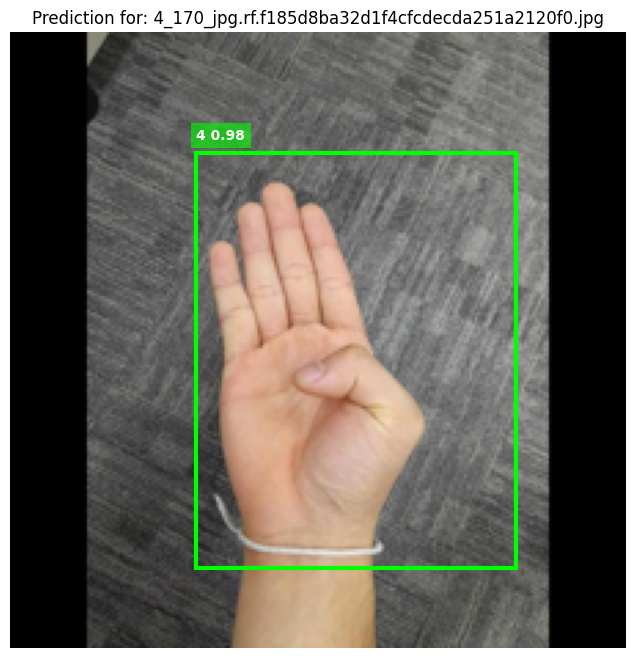

In [45]:
class_names = {0: "0", 1: "1", 2: "2", 3: "3", 4: "4", 5: "5"}
images_path = "../../dataset_resplit_aug_1/test/images/4_170_jpg.rf.f185d8ba32d1f4cfcdecda251a2120f0.jpg"
predict_custom_image(model, images_path, class_names, device)

In [59]:
import onnxruntime as ort
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torchvision import transforms
from torchvision.ops import nms

def predict_custom_image_onnx(onnx_path, image_path, class_names, threshold=0.1):

    # ---------- Load ONNX model ----------
    session = ort.InferenceSession(onnx_path)
    input_name = session.get_inputs()[0].name

    # ---------- Transform ----------
    predict_transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5121, 0.4615, 0.4059],
                             std=[0.2247, 0.2278, 0.2331])
    ])

    img_raw = Image.open(image_path).convert("RGB")
    img_tensor = predict_transform(img_raw).unsqueeze(0)

    # ---------- ONNX Inference ----------
    outputs = session.run(
        None,
        {input_name: img_tensor.numpy().astype(np.float32)}
    )

    pred = torch.tensor(outputs[0])[0]  # แปลงกลับเป็น torch tensor

    # ---------- Post-process ----------
    obj_probs = torch.sigmoid(pred[..., 4])
    mask = obj_probs > threshold

    if not mask.any():
        print(f"⚠️ ไม่พบวัตถุที่มีความมั่นใจเกิน {threshold*100}%")
        plt.imshow(img_raw.resize((224, 224)))
        plt.axis('off')
        plt.show()
        return

    valid_preds = pred[mask]
    valid_obj_probs = obj_probs[mask]

    boxes = []
    for p in valid_preds:
        cx, cy, bw, bh = p[:4]
        x1 = (cx - bw/2) * 224
        y1 = (cy - bh/2) * 224
        x2 = (cx + bw/2) * 224
        y2 = (cy + bh/2) * 224
        boxes.append(torch.stack([x1, y1, x2, y2]))

    boxes = torch.stack(boxes)

    keep = nms(boxes, valid_obj_probs, iou_threshold=0.3)

    plt.figure(figsize=(8, 8))
    plt.imshow(img_raw.resize((224, 224)))
    ax = plt.gca()

    for idx in keep:
        b = boxes[idx].numpy()
        p = valid_preds[idx]
        conf = valid_obj_probs[idx].item()
        cls_id = torch.argmax(p[5:]).item()

        rect = plt.Rectangle((b[0], b[1]),
                             b[2]-b[0],
                             b[3]-b[1],
                             fill=False,
                             color='lime',
                             linewidth=3)

        ax.add_patch(rect)

        label_text = f"{class_names[cls_id]} {conf:.2f}"
        ax.text(b[0], b[1]-5,
                label_text,
                color='white',
                weight='bold',
                bbox=dict(facecolor='lime',
                          alpha=0.6,
                          edgecolor='none'))

    plt.axis('off')
    plt.title(f"Prediction for: {image_path.split('/')[-1]}")
    plt.show()

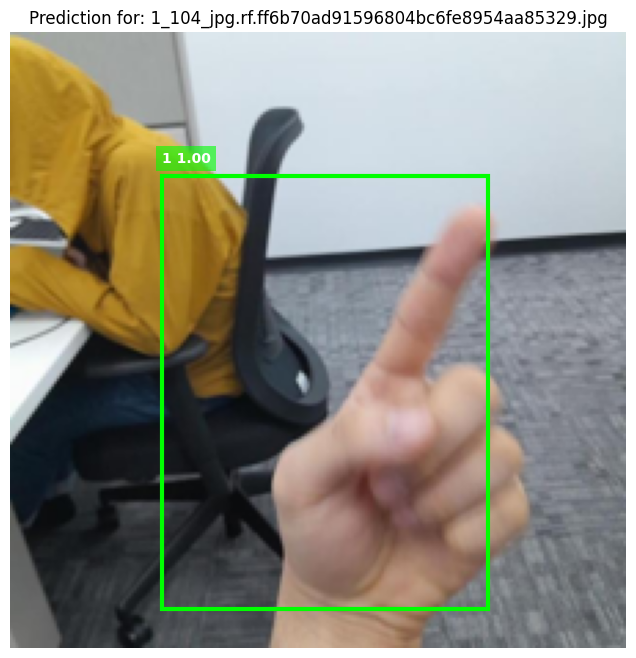

In [61]:
class_names = {0: "0", 1: "1", 2: "2", 3: "3", 4: "4", 5: "5"}

images_path = "../../dataset_resplit_aug_1/test/images/1_104_jpg.rf.ff6b70ad91596804bc6fe8954aa85329.jpg"

predict_custom_image_onnx(
    "../../weights/CNN/outputs/final_model.onnx",
    images_path,
    class_names
)